In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [49]:
data = pd.read_excel('02 Churn-Dataset.xlsx')

In [50]:
# sample data
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,0,0,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,0,0,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,0,0,Yes


In [51]:
# basic info about features
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [52]:
# check if there are missing values
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
numAdminTickets     0
numTechTickets      0
Churn               0
dtype: int64

In [53]:
# change TotalCharges to float and replacing null values with 0 as tenure is 0 for those rows so no charges.
data['TotalCharges'] = data['TotalCharges'].replace(" ", '0').astype(float)

In [54]:
data.shape

(7043, 23)

In [55]:
# check for duplicate rows
data.duplicated().sum()

np.int64(0)

In [56]:
# # conveting binary categorical features to numerical 1 and 0.
# binary_cols = [
#     "gender", "Partner", "Dependents", "PhoneService",
#     "PaperlessBilling"
# ]

# binary_map = {
#     "Yes": 1, "No": 0,
#     "Male": 1, "Female": 0
# }

# for col in binary_cols:
#     data[col] = data[col].map(binary_map).astype(int)

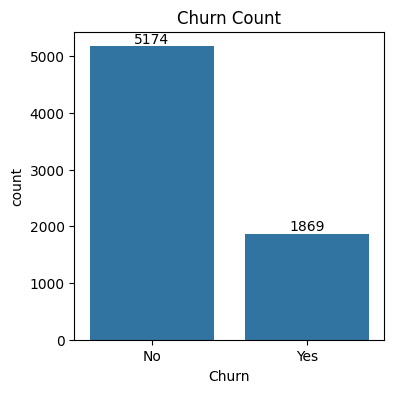

In [57]:
# Count of Customers by Churn
plt.figure(figsize=(4,4))
plot = sns.countplot(x='Churn', data=data)
plot.bar_label(plot.containers[0])
plt.title('Churn Count')
plt.show()


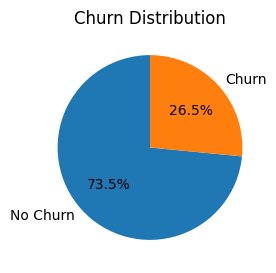

In [58]:
# Pie Chart of Churn Distribution
plt.figure(figsize=(3,3))
pie = data.groupby('Churn').agg({'Churn':'count'})
plt.pie(pie['Churn'], labels=['No Churn', 'Churn'], autopct='%1.1f%%', startangle=90)
plt.title('Churn Distribution')
plt.show()

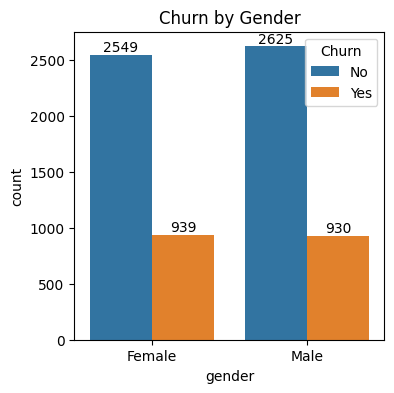

In [59]:
plt.figure(figsize=(4,4))
plot = sns.countplot(x='gender', data=data,hue='Churn')
plot.bar_label(plot.containers[0])
plot.bar_label(plot.containers[1])
plt.title('Churn by Gender')
plt.show()

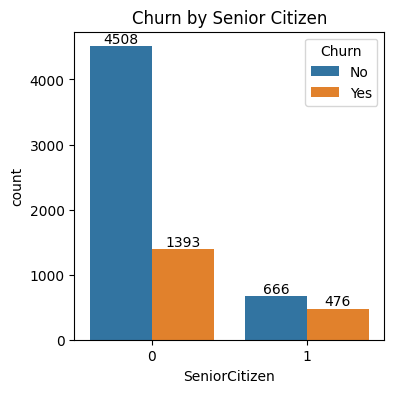

In [60]:
# Churn by Senior Citizen
plt.figure(figsize=(4,4))
plot = sns.countplot(x='SeniorCitizen', data=data,hue='Churn')
plot.bar_label(plot.containers[0])
plot.bar_label(plot.containers[1])

plt.title('Churn by Senior Citizen')
plt.show()

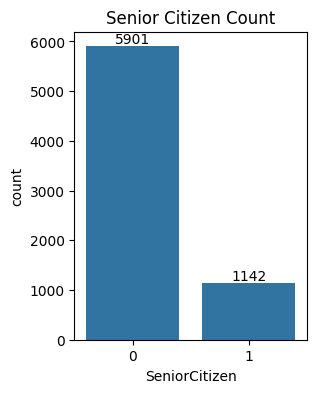

In [61]:
# count of senior citizens
plt.figure(figsize=(3,4))
plot = sns.countplot(x='SeniorCitizen', data=data)
plot.bar_label(plot.containers[0])
plt.title('Senior Citizen Count')
plt.show()

In [64]:
# Filter only senior citizens
senior_df = data[data["SeniorCitizen"] == 1]

# Count churn values
churn_counts = senior_df["Churn"].value_counts()

# Convert to percentages
churn_percentages = churn_counts / churn_counts.sum() * 100
print("Churn Percentages among Senior Citizens:")
print(churn_percentages)


Churn Percentages among Senior Citizens:
Churn
No     58.318739
Yes    41.681261
Name: count, dtype: float64


In [66]:
# Filter only senior citizens
senior_df = data[data["SeniorCitizen"] == 0]

# Count churn values
churn_counts = senior_df["Churn"].value_counts()

# Convert to percentages
churn_percentages = churn_counts / churn_counts.sum() * 100
print("Churn Percentages among non Senior Citizens:")
print(churn_percentages)


Churn Percentages among non Senior Citizens:
Churn
No     76.393832
Yes    23.606168
Name: count, dtype: float64


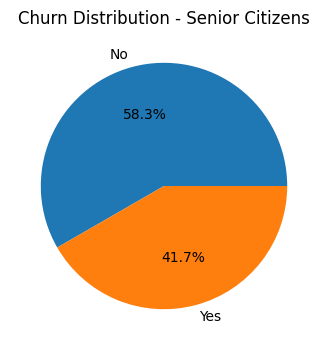

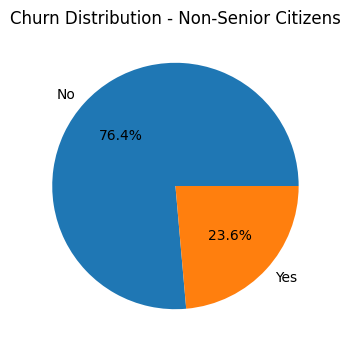

In [68]:
# Pie Charts of Churn Distribution for Senior and Non-Senior Citizens
# Senior Citizens
senior_df = data[data["SeniorCitizen"] == 1]
senior_counts = senior_df["Churn"].value_counts()
senior_percentages = senior_counts / senior_counts.sum() * 100

plt.figure(figsize=(4,4))
plt.pie(senior_percentages, labels=senior_percentages.index, autopct='%1.1f%%')
plt.title("Churn Distribution - Senior Citizens")
plt.show()

# Non-Senior Citizens
non_senior_df = data[data["SeniorCitizen"] == 0]
non_senior_counts = non_senior_df["Churn"].value_counts()
non_senior_percentages = non_senior_counts / non_senior_counts.sum() * 100

plt.figure(figsize=(4,4))
plt.pie(non_senior_percentages, labels=non_senior_percentages.index, autopct='%1.1f%%')
plt.title("Churn Distribution - Non-Senior Citizens")
plt.show()


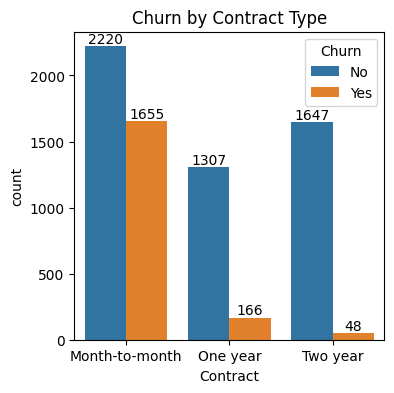

In [71]:
#countplot of customer contract type
plt.figure(figsize=(4,4))
plot = sns.countplot(x='Contract', data=data, hue='Churn')
plot.bar_label(plot.containers[0])
plot.bar_label(plot.containers[1])
plt.title('Churn by Contract Type')
plt.show()

In [ ]:
col = ["MultipleLines", "InternetService", "OnlineSecurity",
       "OnlineBackup", "DeviceProtection", "TechSupport",
       "StreamingTV", "StreamingMovies", "PhoneService"]

plt.figure(figsize=(15,12))
for i in enumerate(col, 1):
    plt.subplot(3,3,i)
    plot = sns.countplot(x=col,data =data, hue=data['Churn'])
    
    plot.bar_label(plot.containers[0])
    plot.bar_label(plot.containers[1])
    plt.title(col)
    plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
    

In [ ]:
# Payment Method vs Churn
plt.figure(figsize=(6,4))
plot = sns.countplot(x='PaymentMethod', data=data, hue='Churn')
plot.bar_label(plot.containers[0])
plot.bar_label(plot.containers[1])
plt.title('Churn by Payment Method')
plt.show()